# Project 1 — Logistic Regression
## Telecom Customer Churn Prediction

**Goal:** Predict whether a customer will churn (leave the service) based on their account features.

This is a **synthetic but realistic dataset** generated in-notebook, so it runs anywhere with no internet/download needed. It mimics a real telecom churn dataset (tenure, charges, contract type, support usage, complaints).

**Pipeline:**
1. Generate & explore data
2. Preprocess (encode categoricals, scale numerics)
3. Train/test split
4. Train Logistic Regression
5. Evaluate (accuracy, precision, recall, F1, confusion matrix, ROC-AUC)
6. Interpret coefficients


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)

np.random.seed(42)
pd.set_option('display.max_columns', None)


## 1. Generate the Dataset

We simulate 2000 customers with features that realistically influence churn:
- `tenure`: months as a customer (longer tenure → less likely to churn)
- `monthly_charges`: higher charges → slightly more likely to churn
- `total_charges`: tenure * monthly_charges (with noise)
- `contract_type`: month-to-month customers churn more than 1-year/2-year contracts
- `tech_support`: having tech support reduces churn
- `num_complaints`: more complaints → more likely to churn
- `age`: mild effect


In [2]:
n = 2000

tenure = np.random.randint(1, 72, n)
monthly_charges = np.round(np.random.normal(70, 25, n).clip(20, 150), 2)
total_charges = np.round(tenure * monthly_charges * np.random.uniform(0.85, 1.15, n), 2)
contract_type = np.random.choice(['Month-to-Month', 'One-Year', 'Two-Year'], n, p=[0.55, 0.25, 0.20])
tech_support = np.random.choice(['Yes', 'No'], n, p=[0.4, 0.6])
num_complaints = np.random.poisson(1.2, n)
age = np.random.randint(18, 75, n)

# Build churn probability from a logistic function of the features (ground truth signal)
contract_effect = np.select(
    [contract_type == 'Month-to-Month', contract_type == 'One-Year', contract_type == 'Two-Year'],
    [1.2, -0.3, -1.0]
)
support_effect = np.where(tech_support == 'No', 0.5, -0.5)

logit = (
    -1.5
    - 0.04 * tenure
    + 0.015 * monthly_charges
    + contract_effect
    + support_effect
    + 0.35 * num_complaints
    - 0.01 * age
)
prob_churn = 1 / (1 + np.exp(-logit))
churn = np.random.binomial(1, prob_churn)

df = pd.DataFrame({
    'tenure': tenure,
    'monthly_charges': monthly_charges,
    'total_charges': total_charges,
    'contract_type': contract_type,
    'tech_support': tech_support,
    'num_complaints': num_complaints,
    'age': age,
    'churn': churn
})

df.head()


,tenure,monthly_charges,total_charges,contract_type,tech_support,num_complaints,age,churn
0,52,86.95,4126.45,One-Year,No,2,31,0
1,15,57.80,752.18,One-Year,Yes,0,26,0
2,61,123.93,7678.49,Month-to-Month,No,1,55,0
3,21,54.86,1184.97,One-Year,No,1,47,0
4,24,88.55,2362.32,Two-Year,No,1,22,1


## 2. Quick EDA

churn
0    0.7265
1    0.2735
Name: proportion, dtype: float64


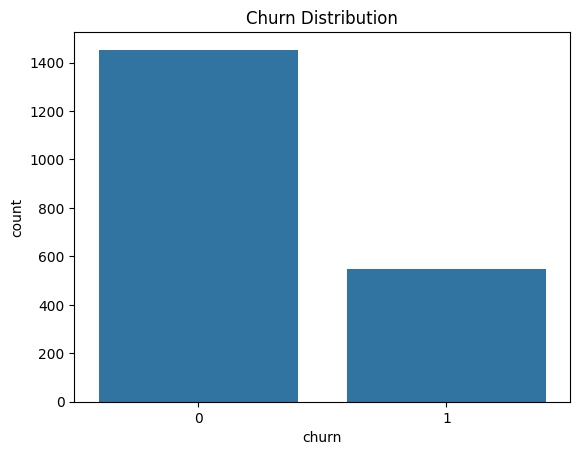

In [3]:
print(df['churn'].value_counts(normalize=True))
sns.countplot(x='churn', data=df)
plt.title('Churn Distribution')
plt.show()


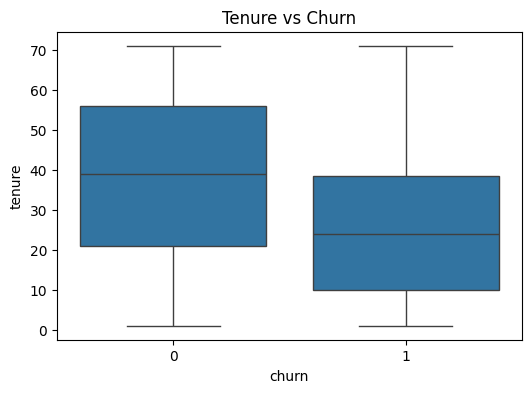

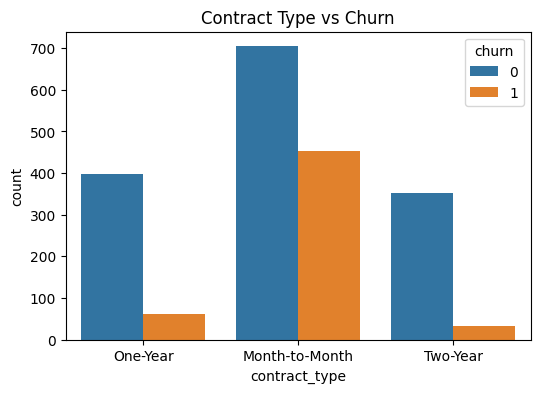

In [4]:
plt.figure(figsize=(6,4))
sns.boxplot(x='churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='contract_type', hue='churn', data=df)
plt.title('Contract Type vs Churn')
plt.show()


## 3. Preprocessing

- Encode `contract_type` (one-hot, since it's nominal/no order)
- Encode `tech_support` (binary → 0/1)
- Scale numeric features (important for logistic regression's regularization + convergence)


In [5]:
df_model = pd.get_dummies(df, columns=['contract_type'], drop_first=True)
df_model['tech_support'] = df_model['tech_support'].map({'Yes': 1, 'No': 0})

X = df_model.drop('churn', axis=1)
y = df_model['churn']

X.head()


,tenure,monthly_charges,total_charges,tech_support,num_complaints,age,contract_type_One-Year,contract_type_Two-Year
0,52,86.95,4126.45,0,2,31,True,False
1,15,57.80,752.18,1,0,26,True,False
2,61,123.93,7678.49,0,1,55,False,False
3,21,54.86,1184.97,0,1,47,True,False
4,24,88.55,2362.32,0,1,22,False,True


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 4. Train Logistic Regression

We'll use `class_weight='balanced'` since churn is usually imbalanced (fewer churners than non-churners), and `C=1.0` as a starting regularization strength.


In [7]:
model = LogisticRegression(C=1.0, penalty='l2', class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 5. Evaluate

In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print()
print(classification_report(y_test, y_pred))


Accuracy: 0.705
Precision: 0.4748603351955307
Recall: 0.7798165137614679
F1 Score: 0.5902777777777778
ROC-AUC: 0.8161669661716952

              precision    recall  f1-score   support

           0       0.89      0.68      0.77       291
           1       0.47      0.78      0.59       109

    accuracy                           0.70       400
   macro avg       0.68      0.73      0.68       400
weighted avg       0.78      0.70      0.72       400



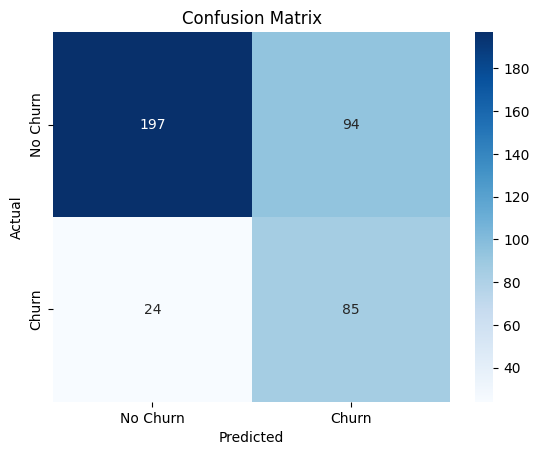

In [9]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


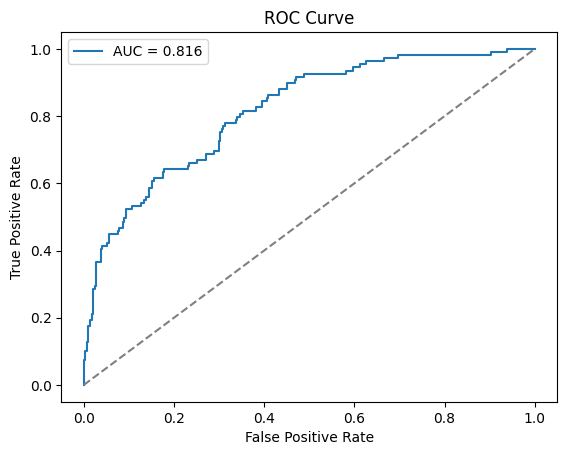

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


## 6. Interpret Coefficients

The sign and magnitude of each coefficient tells us how that feature (in standardized units) affects the **log-odds of churn**. Positive = increases churn risk, negative = decreases it.


In [11]:
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0],
    'odds_ratio': np.exp(model.coef_[0])
}).sort_values('coefficient', ascending=False)

coef_df


,feature,coefficient,odds_ratio
4,num_complaints,0.562473,1.755008
2,total_charges,0.229718,1.258245
1,monthly_charges,0.192922,1.212788
5,age,-0.183456,0.832388
3,tech_support,-0.507210,0.602173
6,contract_type_One-Year,-0.736324,0.478871
7,contract_type_Two-Year,-0.887692,0.411605
0,tenure,-1.028803,0.357435


## 7. Takeaways

- Month-to-month contracts, higher complaint counts, and lack of tech support **increase** churn risk — matches business intuition.
- Longer tenure and having tech support **reduce** churn risk.
- `class_weight='balanced'` helped recall on the churn class — worth checking the tradeoff with precision depending on business cost (is it worse to miss a churner, or to wrongly flag a loyal customer?).
- Next steps you could try: tune `C` with `GridSearchCV`, try `penalty='l1'` to see which features get zeroed out, or adjust the decision threshold instead of the default 0.5.

---

# Project 2 — Your Turn (Practice Alone)

**Dataset:** Titanic — passenger survival prediction (binary classification, same algorithm, very different feature types).

Load it with:
```python
import seaborn as sns
titanic = sns.load_dataset('titanic')
```

**Your tasks:**
1. Explore the data — check missing values (`age`, `deck`, `embarked` all have gaps)
2. Decide how to handle missing values (drop? impute?)
3. Encode categorical features (`sex`, `embarked`, `class`, etc.)
4. Scale numeric features
5. Train a Logistic Regression model to predict `survived`
6. Evaluate with accuracy, precision, recall, F1, confusion matrix, ROC-AUC
7. Interpret the coefficients — which features increased/decreased survival odds?

Try it, and send me your notebook or results when you're done — I'll review it before we move to **KNN**.
